# Uniaxial Concrete

This notebook runs some simple uniaxial strain-driven simulations using some common {ref}`xara.UniaxialMaterial` formulations for concrete. The methods used are described with more detail in the {ref}`uniaxial plasticity example <material-0002>`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Basic Setup

For convenience, import unit constants from the {ref}`units` submodule and define parameters.

In [3]:
from xara.units.english import ksi, psi
from math import sqrt

# nominal concrete compressive strength
fc = -8.5*ksi              # Compressive strength
Ec = 57*ksi*sqrt(-fc/psi)  # Compressive Elastic Modulus

# unconfined concrete
ec0 = -0.003             # strain at maximum compressive strength
fc2U = 0.2*fc            # ultimate compressive stress
ecu = -0.01              # strain at ultimate stress
_lambda = 0.1            # ratio between unloading slope at ecu and initial slope Ec

# tensile-strength properties
ftU = abs(0.14*fc)         # tensile strength (positive)
Ets = ftU/0.002            # tension softening stiffness (Concrete02)
epstu = 1e-4               # strain at which tensile softening starts (Concrete04)

Use `numpy` functions to generate a simple cyclic strain history and plot it with `matplotliib`:

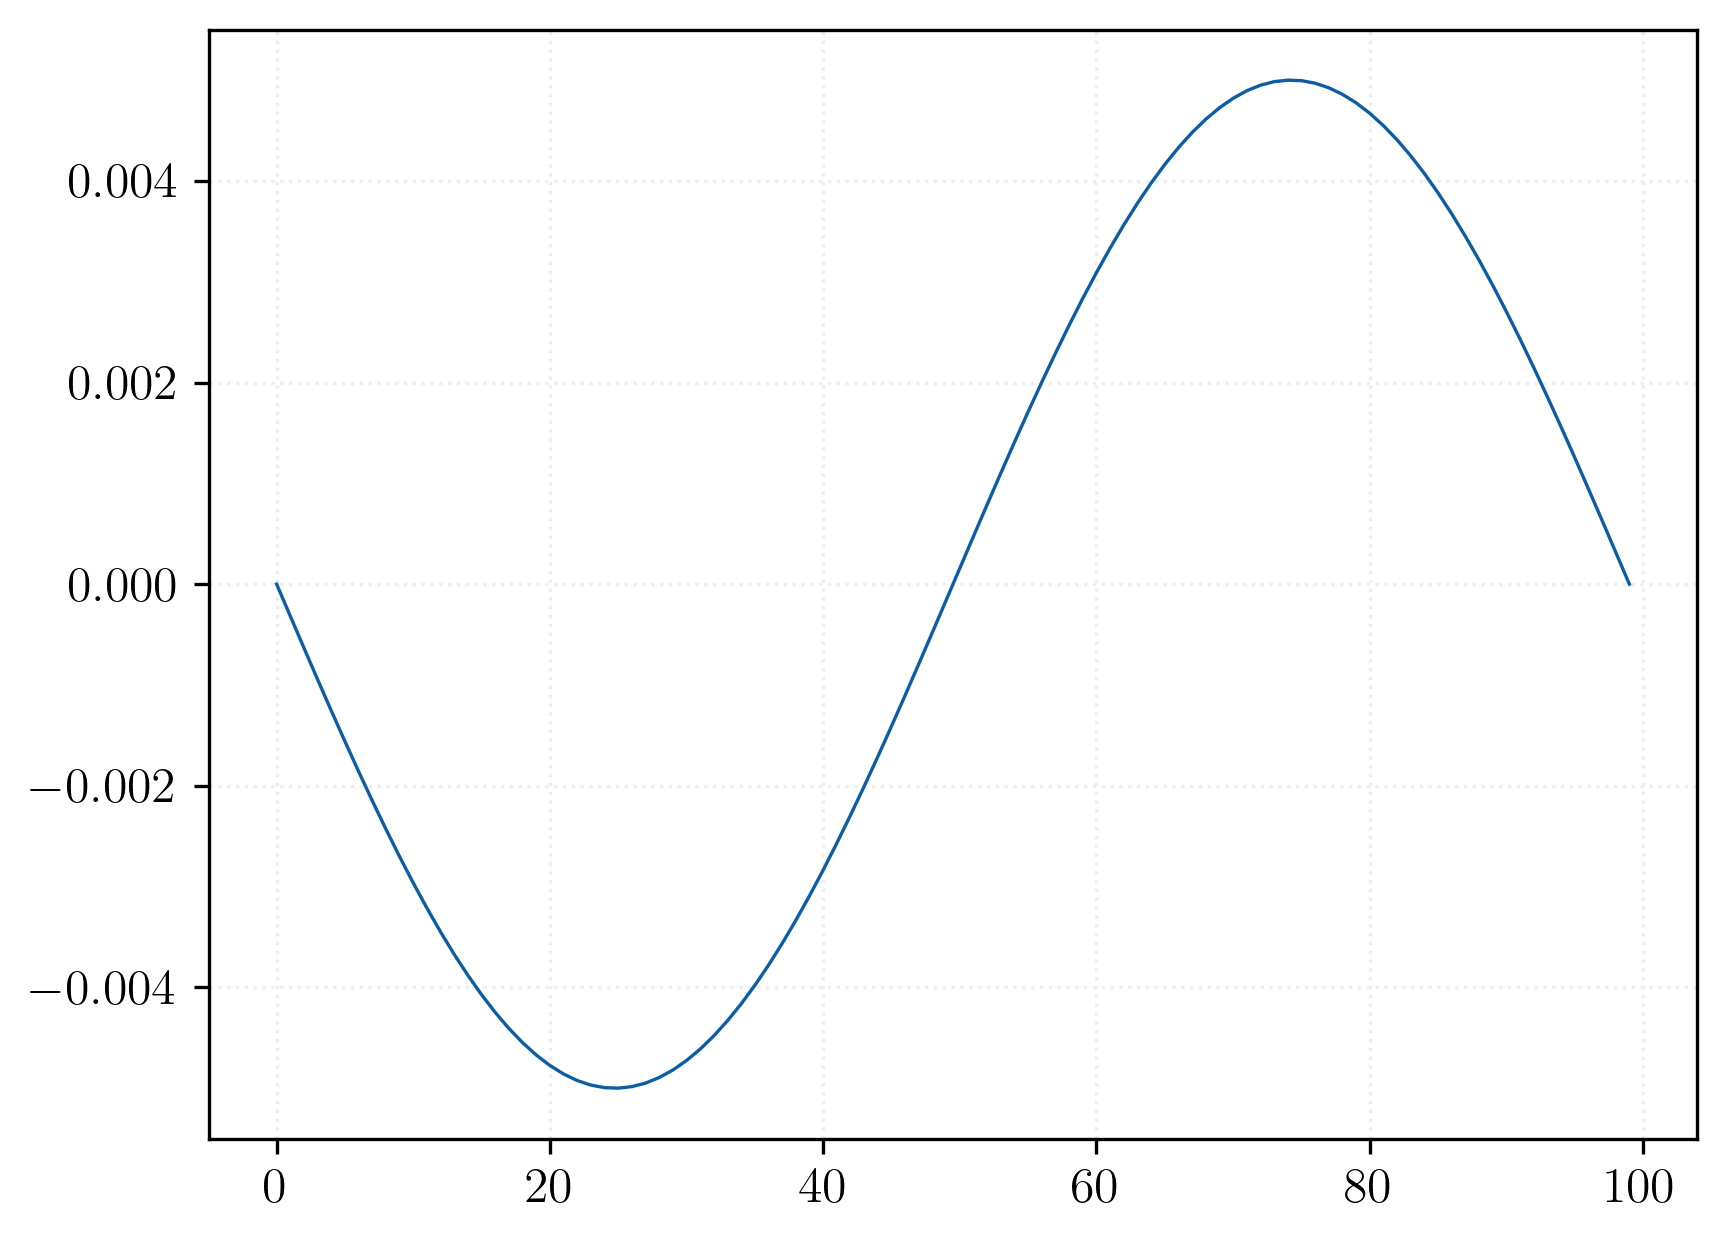

In [4]:
from numpy import sin, linspace, pi

strain = -0.005*sin(linspace(0, 2.0*pi, 100))
plt.plot(strain);

Next create a {ref}`Concrete01` material.

In [5]:
import xara 

concrete01 = xara.UniaxialMaterial("Concrete01", 
    Fc=fc, 
    nu=0.2, 
    ec0=ec0, 
    Fcu=fc2U, 
    ecu=ecu, 
)

Use this {py:class}`xara.UniaxialMaterial` object to compute the stress response at each strain in our history.

In [6]:
stress = []

with concrete01 as tmp:
    for e in strain:
        stress.append(tmp.getStress(e, commit=True)/fc)


Now that the stress and strain are stored, they can be plotted using `matplotlib`

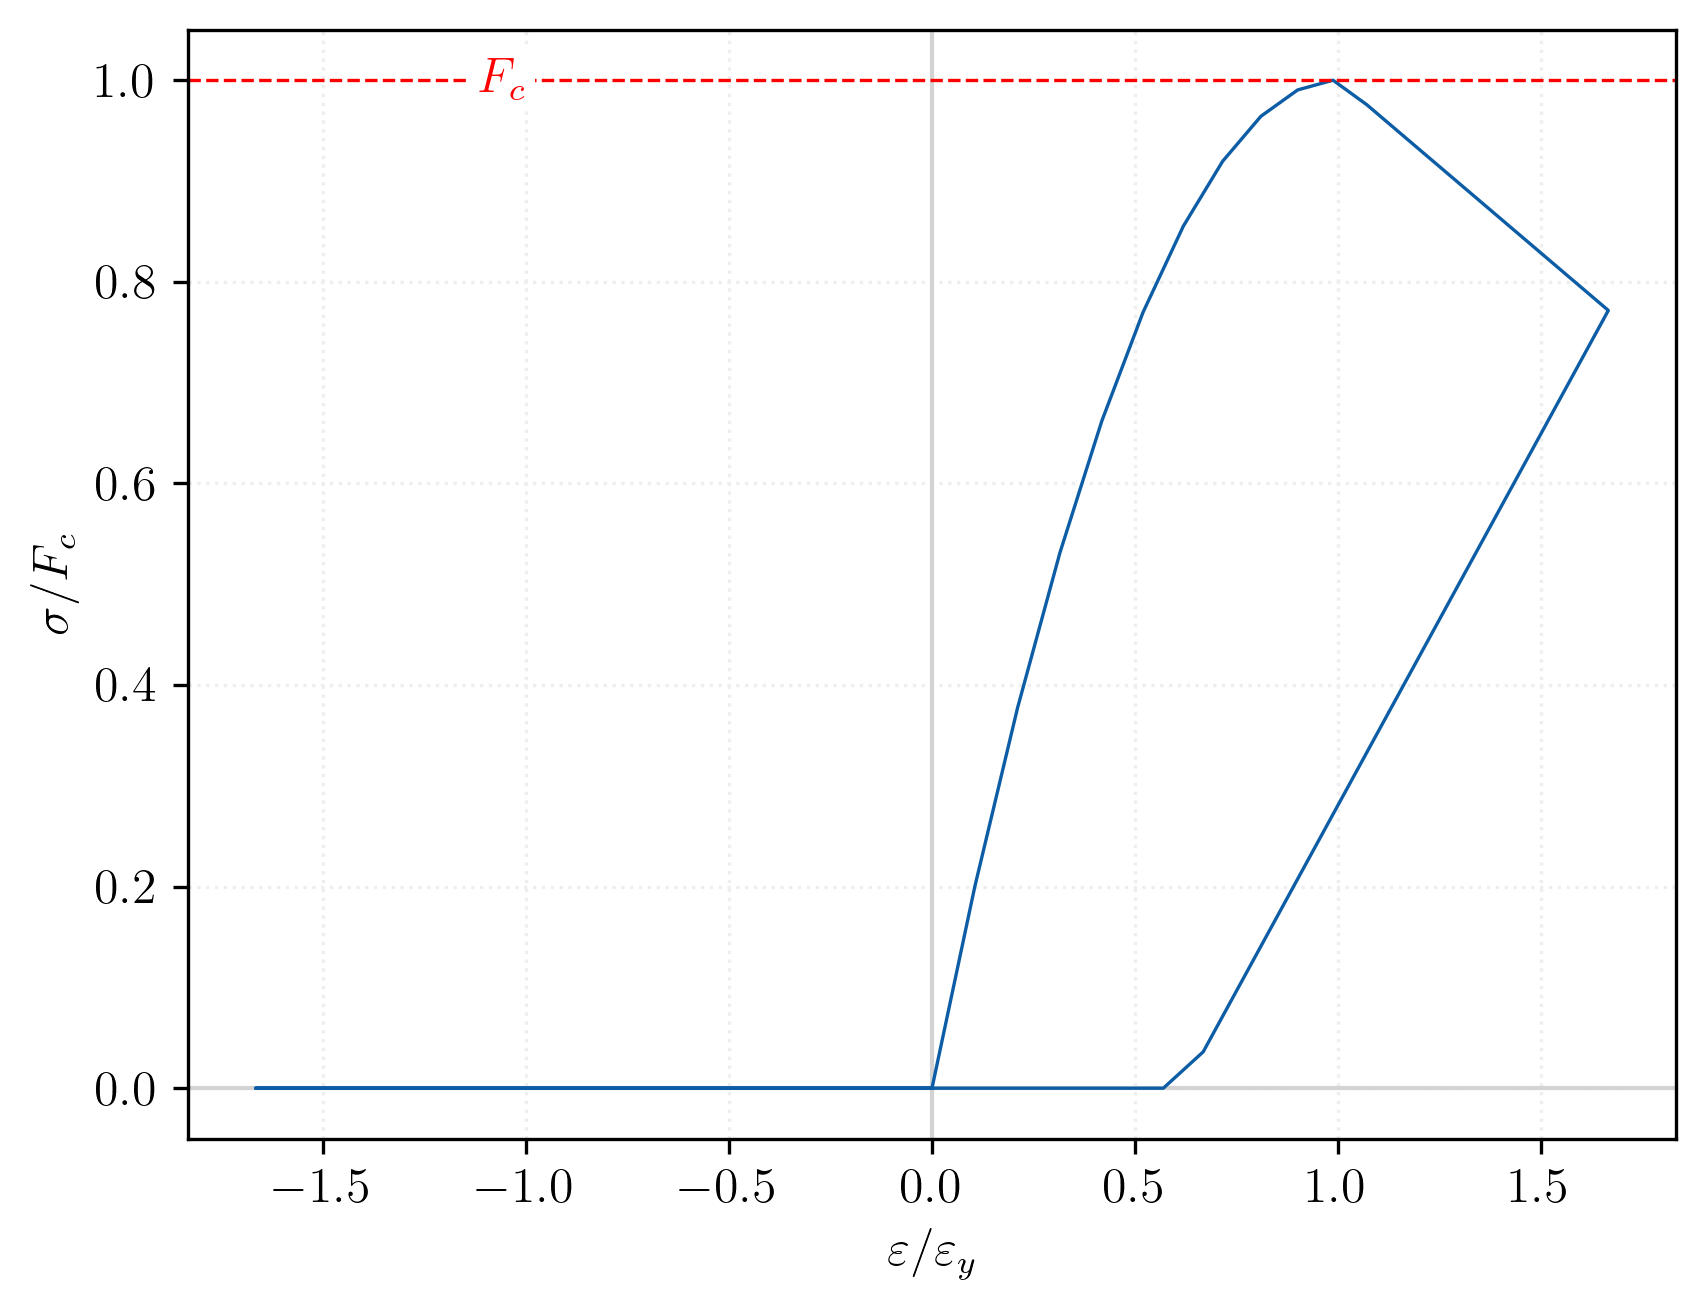

In [7]:

# create a plotting figure
fig, ax = plt.subplots()
ax.axhline(0, color='lightgrey', linestyle='-', linewidth=1)
ax.axvline(0, color='lightgrey', linestyle='-', linewidth=1)
ln = ax.plot(strain/ec0, stress)

# mark_slope(ax, ln[0], 0.25, 0.75, iend=20, label="$E$", color='k', ls='--')
ax.axhline(y=1, color='r', linestyle='--')
ax.text(-1, 1, r"$F_c$", color='r', va='center', ha='right', bbox=dict(facecolor='white', edgecolor='none', pad=2.0))

ax.set_xlabel(r"$\varepsilon/\varepsilon_y$")
ax.set_ylabel(r"$\sigma/F_c$");


## Concrete Materials

The same basic procedure is now applied with multiple concrete material formulations. 
For each formulation of interest, an instance of {ref}`xara.UniaxialMaterial` is created in an array, `ConcreteMaterials`, which will allow us to conveniently loop through cases.

{ref}`Concrete01` and {ref}`Concrete02` are both based on Todeschini's piecewise parabola.

In [8]:
ConcreteMaterials = [
    xara.UniaxialMaterial(
        type="Concrete01",
        nu=0.2,
        Fc=fc,
        ec0=ec0,
        Fcu=fc2U,
        ecu=ecu,#-1,#
        # Ec = Ec,
    ),
    xara.UniaxialMaterial(
        type="Concrete02",
        nu=0.2,
        Fc=fc,
        ec0=ec0,
        Fcu=fc2U,
        ecu=ecu,
        ft=ftU,
        Ets=Ets,
        # Ec = Ec,
    ),
    xara.UniaxialMaterial(
        type="Concrete04",
        Fc=fc,
        nu=0.2,
        ec0=ec0,
        Fcu=fc2U, ###
        ecu=ecu,#-1,#
        Ec = Ec,
        Ft = ftU,
        epstu=1e-4
    ),

    xara.UniaxialMaterial("Continuum", 
        xara.MultiaxialMaterial("FariaPlasticDamage",
            E=Ec, 
            nu = 0.2,
            Fc = fc,
            scale_peak=True,
            Ft = ftU,
            beta=0.0,
            Ap=2.5, An=3, Bn=0.75
        ),
    ),
]


### Compression Envelope

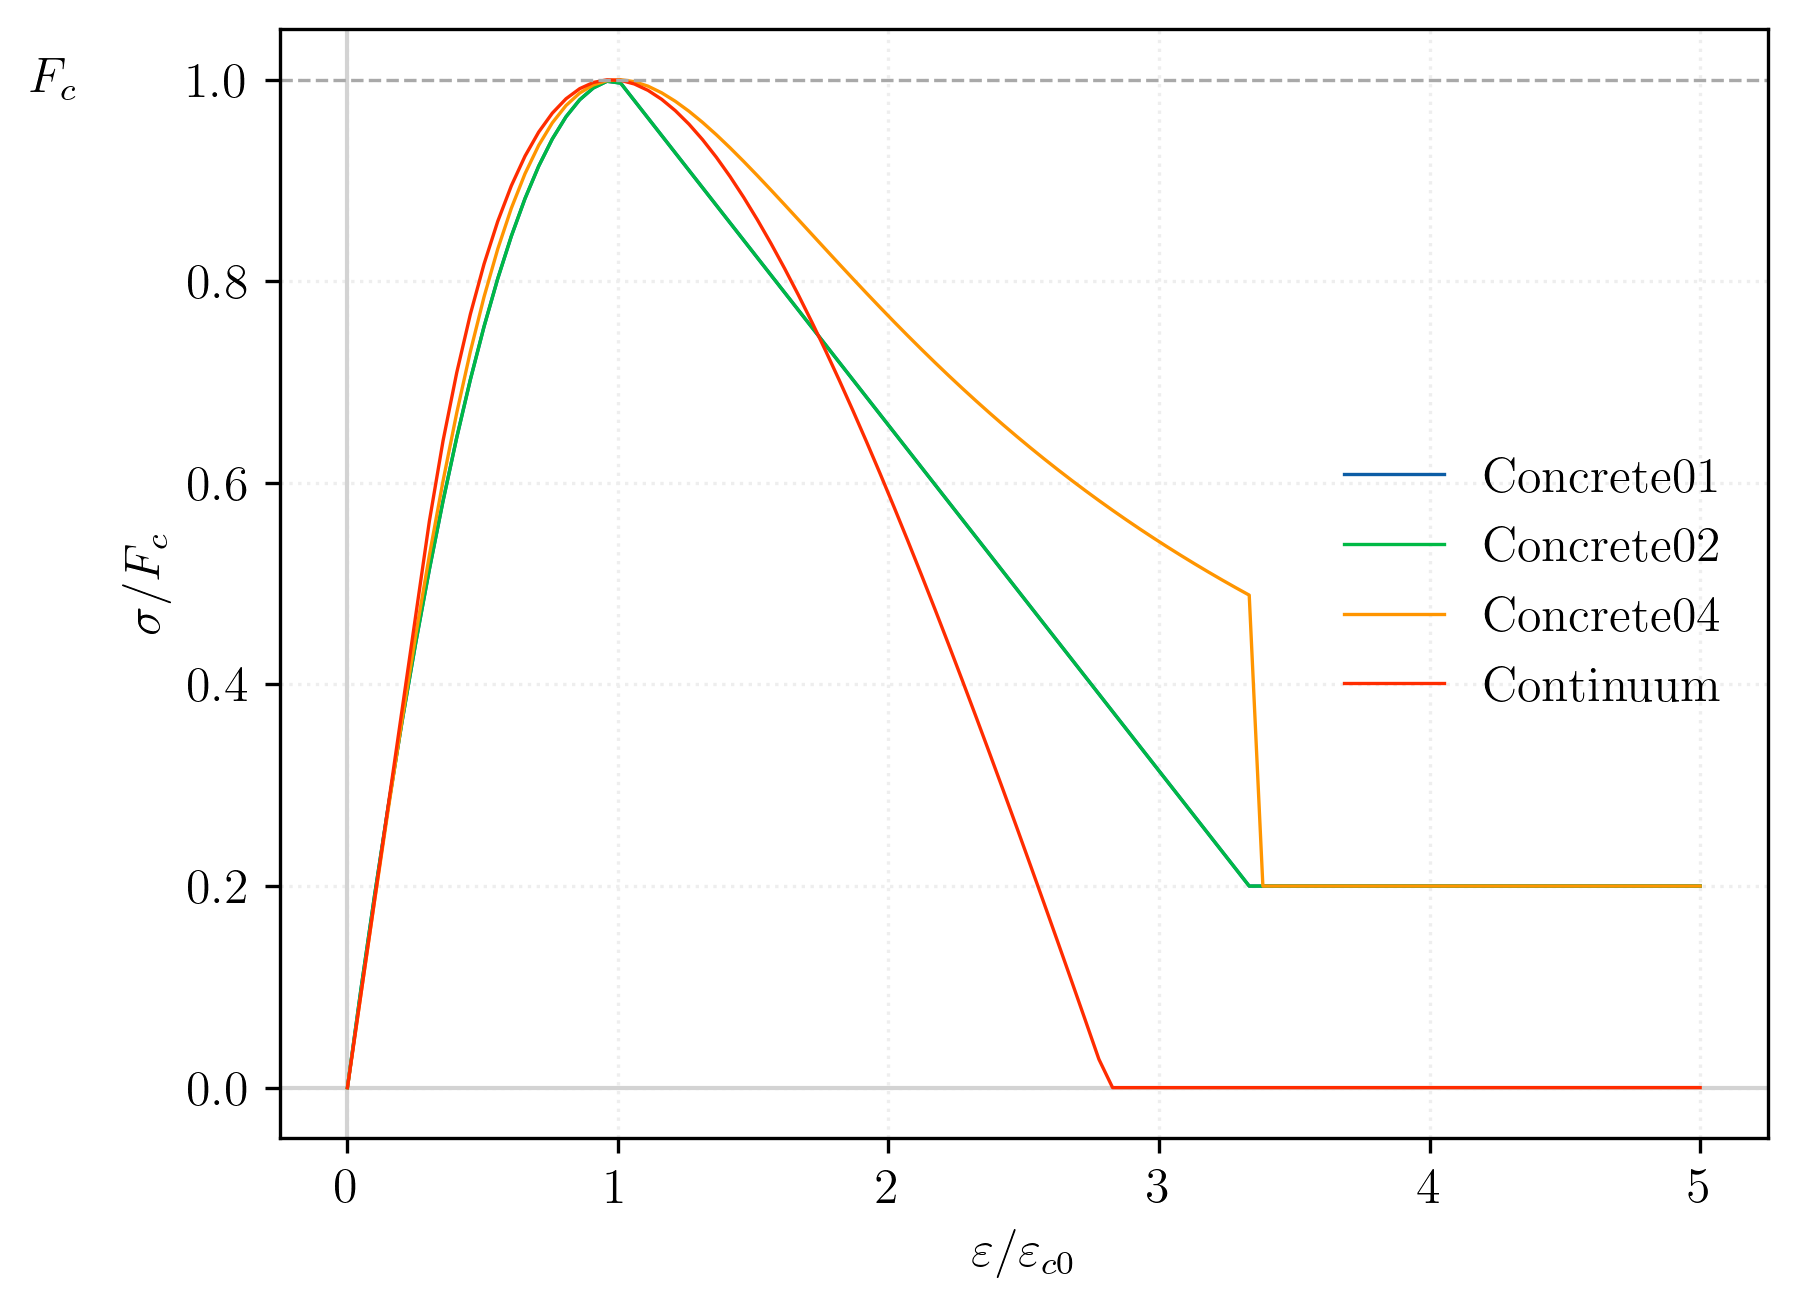

In [10]:
fig, ax = plt.subplots()
ax.axhline(0, color='lightgrey', linestyle='-', linewidth=1)
ax.axvline(0, color='lightgrey', linestyle='-', linewidth=1)

strain = np.linspace(0, 5*ec0, 100)


for material in ConcreteMaterials:
    with material as tmp:
        ln = ax.plot(strain/ec0, 
                    [tmp.getStress(e, commit=True)/fc for e in strain], label=material.type)


# Draw a horizontal line at the yield stress Fy
ax.axhline(y=1, color='darkgrey', linestyle='--')
ax.text(-1, 1, r"$F_c$", color='k', va='center', ha='right', bbox=dict(facecolor='white', edgecolor='none', pad=2.0))

ax.set_xlabel(r"$\varepsilon/\varepsilon_{c0}$")
ax.set_ylabel(r"$\sigma/F_c$");
ax.legend();

### Tension Envelope

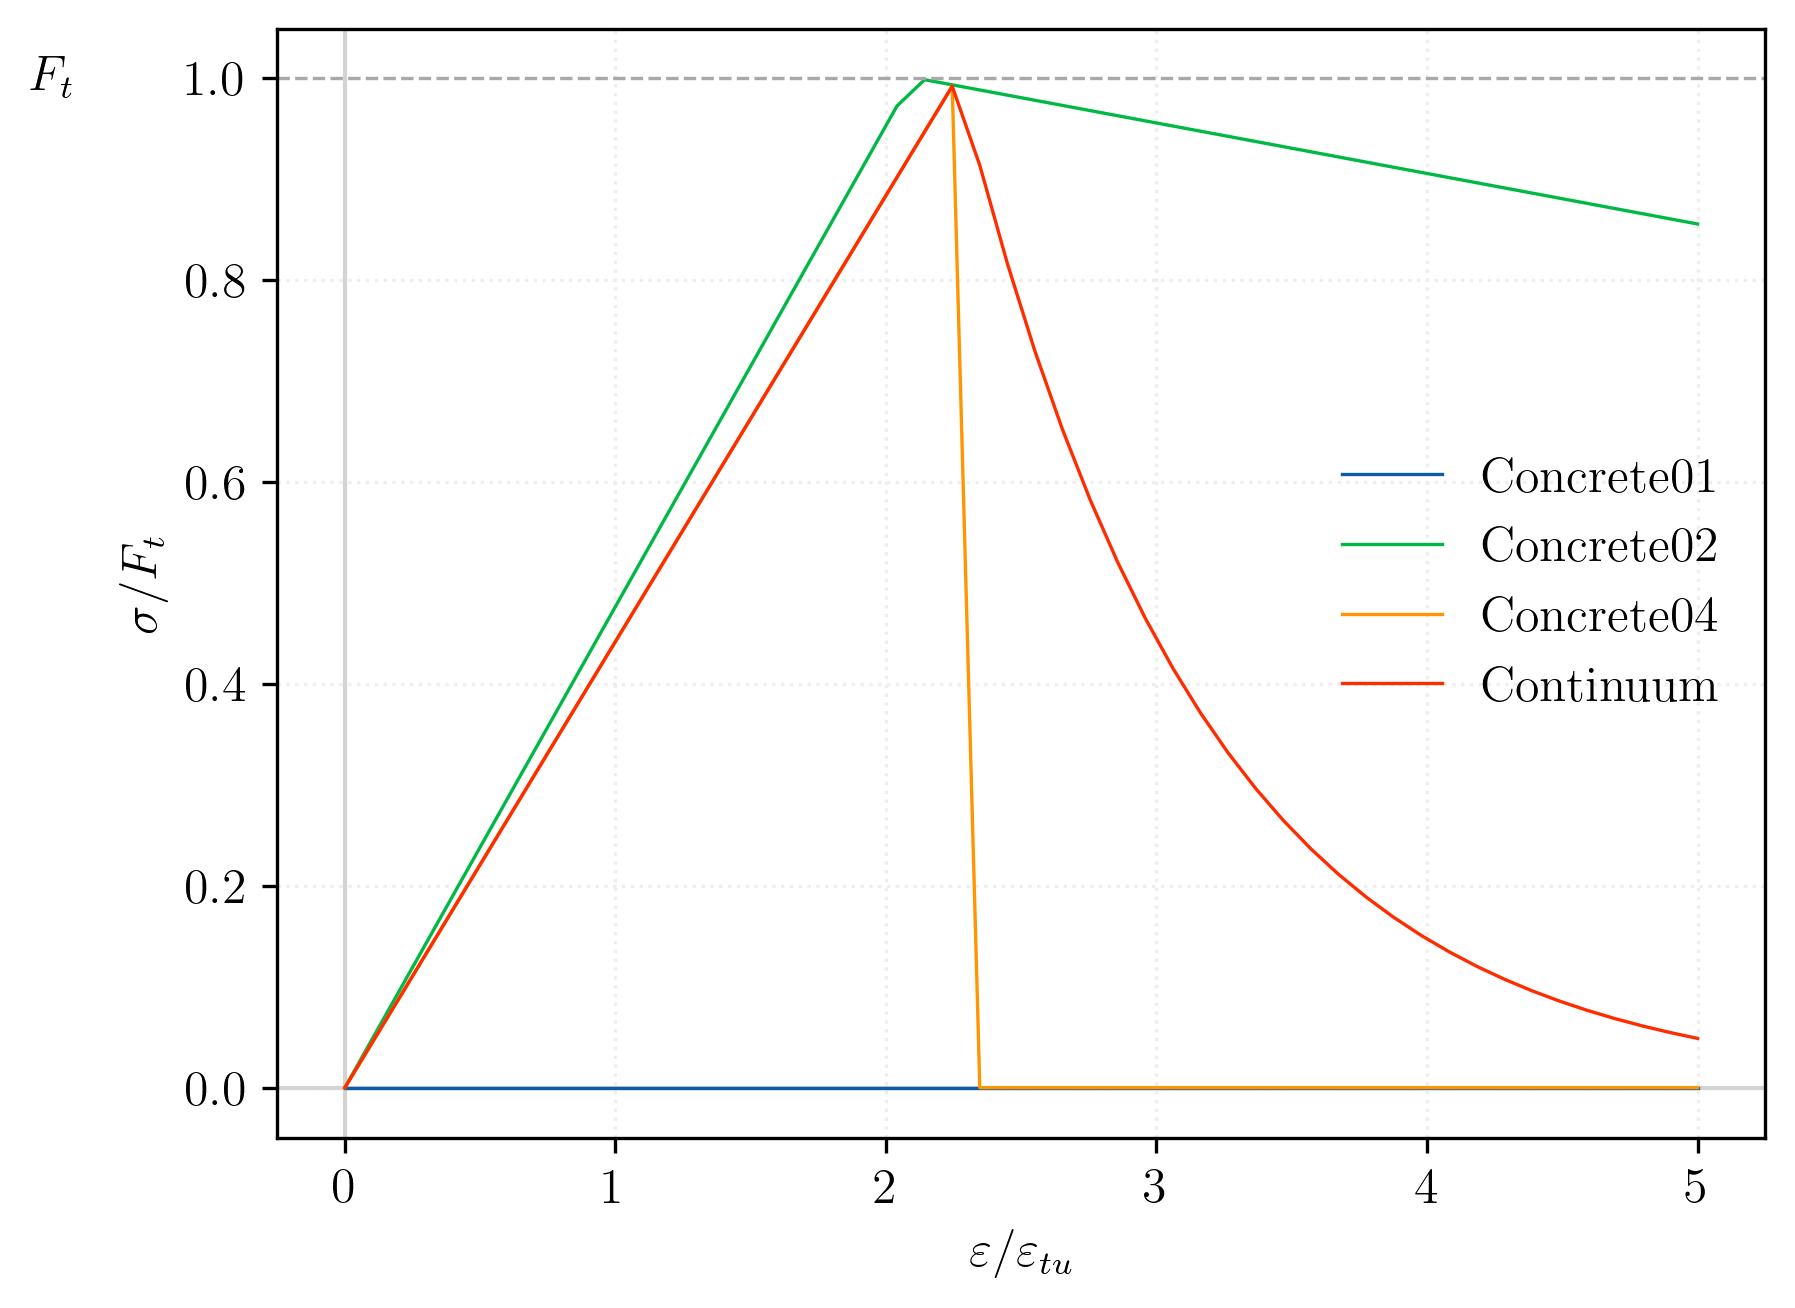

In [11]:
fig, ax = plt.subplots()
ax.axhline(0, color='lightgrey', linestyle='-', linewidth=1)
ax.axvline(0, color='lightgrey', linestyle='-', linewidth=1)

strain = np.linspace(0, 5*epstu, 50)


for material in ConcreteMaterials:
    with material as tmp:
        ln = ax.plot(strain/epstu, 
                    [tmp.getStress(e, commit=True)/ftU for e in strain], 
                    label=material.type)


# Draw a horizontal line at the yield stress Fy
ax.axhline(y=1, color='darkgrey', linestyle='--')
ax.text(-1, 1, r"$F_t$", color='k', va='center', ha='right', bbox=dict(facecolor='white', edgecolor='none', pad=2.0))

ax.set_xlabel(r"$\varepsilon/\varepsilon_{tu}$")
ax.set_ylabel(r"$\sigma/F_t$");
ax.legend();

### Cyclic Response

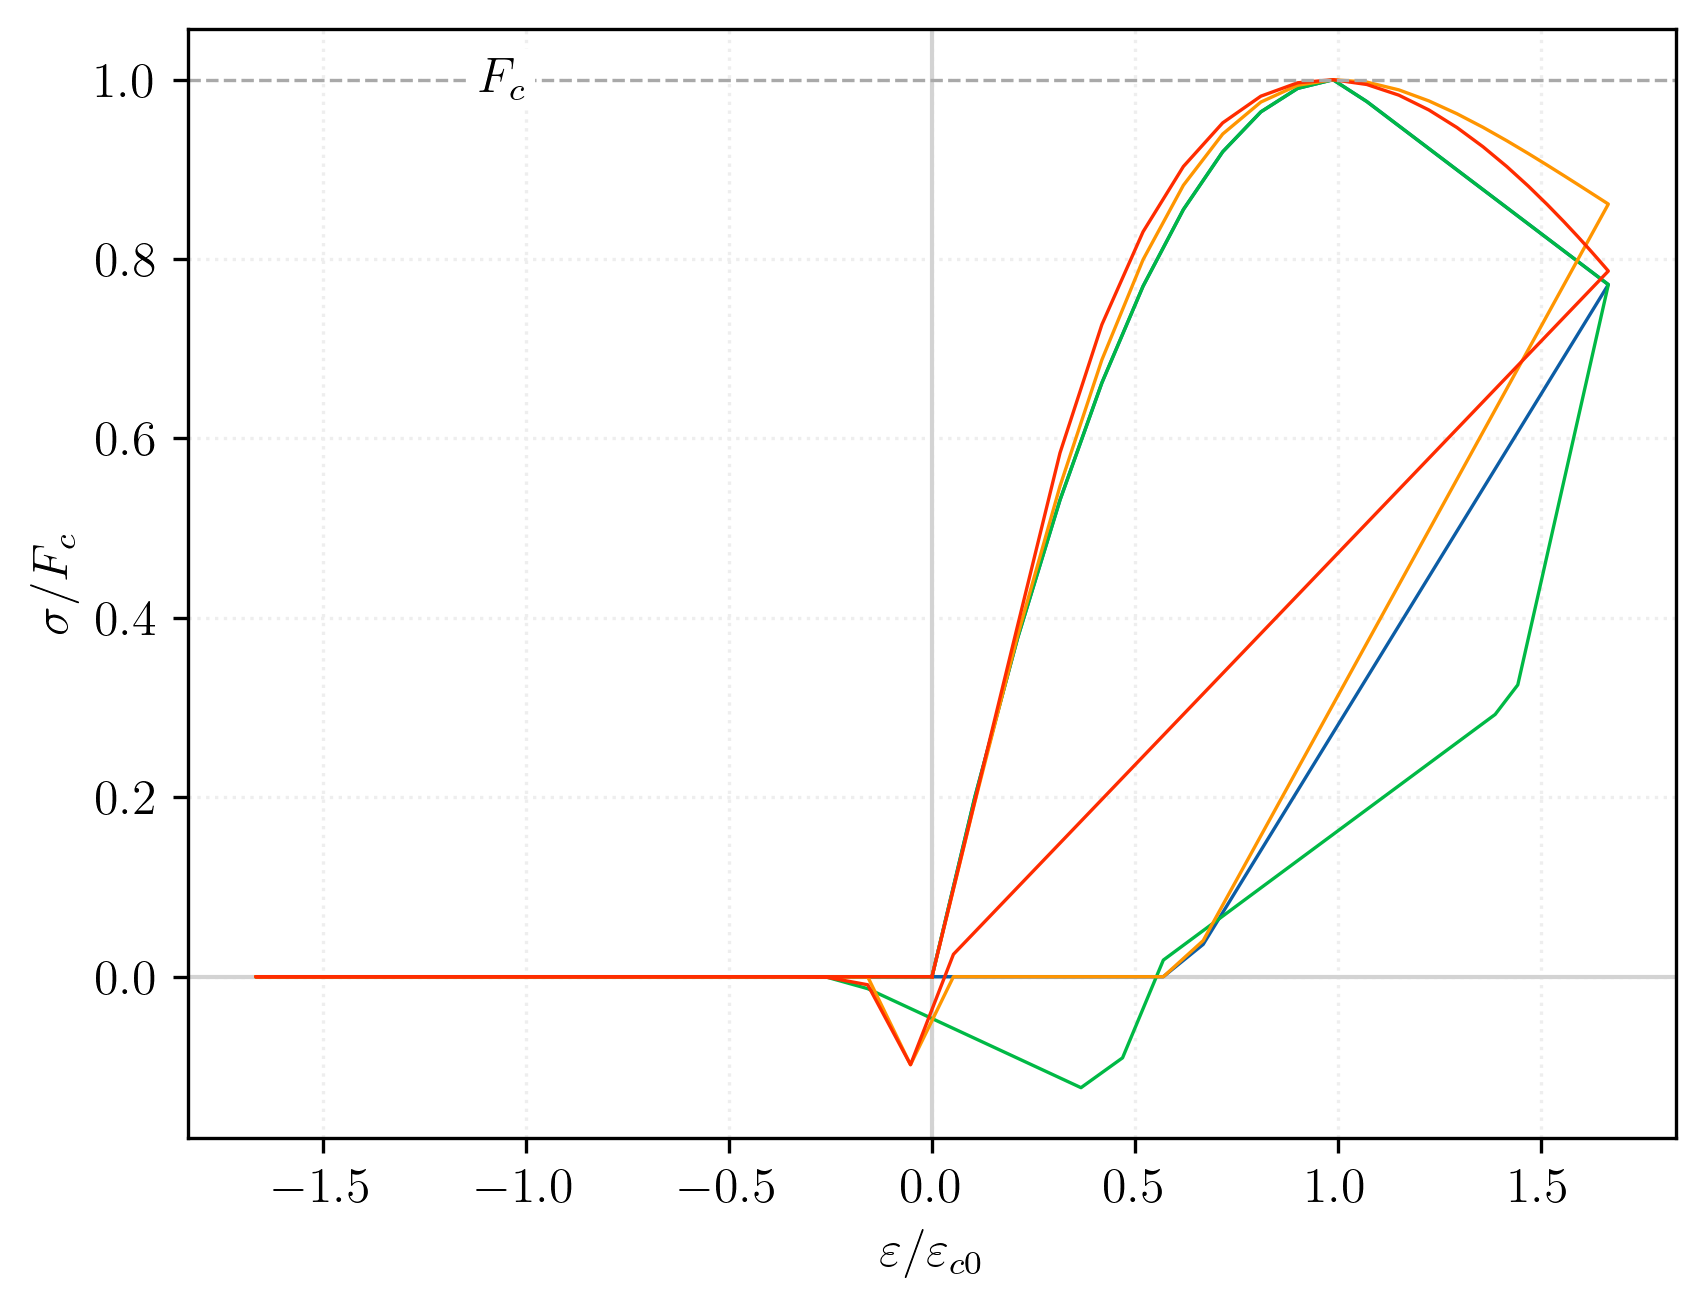

In [12]:
fig, ax = plt.subplots()
ax.axhline(0, color='lightgrey', linestyle='-', linewidth=1)
ax.axvline(0, color='lightgrey', linestyle='-', linewidth=1)

strain = -0.005*sin(linspace(0, 2.0*pi, 100))


for material in ConcreteMaterials:
    with material as tmp:
        ln = ax.plot(strain/ec0, 
                    [tmp.getStress(e, commit=True)/fc for e in strain])

# Draw a horizontal line at the yield stress Fy
ax.axhline(y=1, color='darkgrey', linestyle='--')
ax.text(-1, 1, r"$F_c$", color='k', va='center', ha='right', bbox=dict(facecolor='white', edgecolor='none', pad=2.0))

ax.set_xlabel(r"$\varepsilon/\varepsilon_{c0}$")
ax.set_ylabel(r"$\sigma/F_c$");